# Benchmarking



## Connect-4

<!-- ### Tổng quan 

* **Tên tập dữ liệu:** Connect-4 Dataset
* **Nguồn cung cấp:** UCI Machine Learning Repository
* **Tác giả/Người đóng góp:** John Tromp (1995)
* **Số lượng mẫu (Instances):** 67.557
* **Số lượng đặc trưng (Features):** 42 (không tính cột nhãn)
* **Giá trị khuyết thiếu (Missing Values):** Không có (0%)


### Mô tả 

Tập dữ liệu này không lưu trữ toàn bộ các ván cờ từ đầu đến cuối, mà tập trung bắt chụp (snapshot) tất cả các trạng thái hợp lệ của bàn cờ Connect-4 (kích thước 7 cột x 6 hàng) chính xác tại thời điểm sau 8 nước đi (8-ply positions).

Trạng thái bàn cờ trong tập dữ liệu thỏa mãn hai điều kiện sau:

1. Chưa có bất kỳ người chơi nào giành chiến thắng tại thời điểm nước thứ 8.
2. Nước đi tiếp theo không mang tính bắt buộc (not forced) – nghĩa là ván cờ vẫn mang tính chiến thuật cao và người chơi có nhiều hơn một sự lựa chọn.

Theo quy ước của tập dữ liệu, người đi trước được gắn nhãn là `x` và người đi sau là `o`.


### Thông tin Thuộc tính 

Dữ liệu được biểu diễn dưới dạng bảng phân loại (categorical) với tổng cộng 43 cột:

* **Đặc trưng đầu vào (42 cột):** Tương ứng với 42 ô vuông trên bàn cờ. Mỗi ô sẽ nhận một trong ba giá trị:
    * `x`: Ô đã được người chơi thứ nhất đánh.
    * `o`: Ô đã được người chơi thứ hai đánh.
    * `b`: Ô trống (blank - chưa ai đánh).


* **Biến mục tiêu (Class Label):** Cột cuối cùng thể hiện kết quả lý thuyết trò chơi dành cho người chơi thứ nhất (`x`), với giả định rằng cả hai người chơi đều thực hiện các chiến thuật hoàn hảo nhất từ nước thứ 9 trở đi. Cột này được phân thành 3 lớp:
    * `win`: x chắc chắn thắng (44.473 mẫu, chiếm khoảng 65.83%).
    * `loss`: x chắc chắn thua (16.635 mẫu, chiếm khoảng 24.62%).
    * `draw`: Ván cờ hòa (6.449 mẫu, chiếm khoảng 9.55%).



### Đặc tính trong Khai thác Dữ liệu

Nếu bạn định dùng tập dữ liệu này để thực nghiệm (benchmarking) thuật toán, đây là những đặc điểm học thuật cần nhấn mạnh:

* **Bản chất "Dày đặc" (Dense Dataset):** Khác với dữ liệu giao dịch bán lẻ thường rất "thưa" (sparse), Connect-4 là một tập dữ liệu cực kỳ "dày đặc". Mỗi dòng dữ liệu luôn có độ dài cố định.
* **Thách thức Bùng nổ tổ hợp:** Sự phân bố lặp lại của các giá trị `x`, `o`, `b` khiến các phần tử (items) có tần suất xuất hiện cùng nhau cực kỳ cao. Điều này sinh ra vô số các "tập phổ biến dài" (long frequent itemsets) khi khai thác luật kết hợp.
* **Tiêu chuẩn Đánh giá (Gold Standard):** Nhờ đặc tính trên, Connect-4 thường xuyên được các nhà nghiên cứu sử dụng làm thước đo chuẩn để bộc lộ nhược điểm của các thuật toán sinh ứng viên (như Apriori) và chứng minh sức mạnh của các cấu trúc nén/cắt tỉa dữ liệu (như FP-Tree trong thuật toán FP-Growth).


### Tiền xử lý
Để quá trình chạy benchmark diễn ra chuyên nghiệp và chính xác, tập dữ liệu này đòi hỏi một vài bước chuyển đổi:

1. **Chuyển đổi định dạng thuật toán:** Nếu chạy thuật toán Khai thác tập phổ biến, cần ánh xạ các chuỗi ký tự (`x`, `o`, `b` tại các vị trí) thành các định danh số nguyên (Integer IDs) duy nhất theo chuẩn định dạng của các bộ thư viện khai phá dữ liệu.
2. **Xử lý mất cân bằng lớp (Class Imbalance):** Nếu áp dụng cho bài toán Phân lớp (Classification) trong Machine Learning, cần lưu ý biến mục tiêu đang bị lệch rất mạnh về lớp `win` (65.83%). Việc cân bằng lại tập dữ liệu sẽ giúp mô hình dự đoán tránh bị thiên lệch. -->

### Load Dependencies

In [ ]:
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
# Thiết lập backend đồ họa mặc định
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
# Load Logger OOP từ file ngoài
include("../src/logger.jl")
# # Load các hàm Hỗ trợ Đánh giá
include("../src/utils.jl")
# include("../src/eval.jl")
using .Utils
# success(logger, "Helper loaded")
logger = Logger()


success(logger, "Dependencies loaded")


### Transform Data 

In [1]:
# 🛠️ Bước 2: Biến đổi dữ liệu từ .zip -> .dat (SPMF format)
# Converts categorical attributes to integer encoding using Utils module.

zip_path = "../data/benchmark/connect+4.zip"
extract_dir = "../data/benchmark/connect+4/"
raw_data_name = "connect-4.data"
spmf_out_path = "../data/benchmark/connect-4.dat"

Utils.transform_spmf(zip_path, extract_dir, raw_data_name, spmf_out_path, logger)


LoadError: UndefVarError: `Utils` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [8]:
# using CSV, DataFrames, Plots, ProgressMeter, Statistics
# using Plots.PlotMeasures

# include("../src/FPGrowth.jl")
# using .FPGrowth

# include("../src/logger.jl")
# logger = Logger()

# include("../src/utils.jl")
# include("../src/eval.jl")
# using .Utils
# success(logger, "Dependencies loaded!")


### Configure Paramaters

In [ ]:
config = Dict{String, Any}(
    "dataset_path"         => "../data/benchmark/transactional_T10I4D100K.csv",
    "java_path"       => "java",
    "spmf_path"        => "../spmf.jar",
    "baseline_result"     => "../results/connect4_spmf_out.txt",
    "performance_result"      => "../results/connect4_performance.csv",
    "scalability_result" => "../results/connect4_scalability.csv",
    "min_sups"                   => [0.75, 0.80, 0.85, 0.9],
    "n_benchmark_runs"           => 5,
    "data_ratios"                => [0.25, 0.50, 0.75, 1.0],
    "Minimum Support" => 0.90,
)
success(logger, "Config loaded")


[success] Config loaded – dataset: connect-4.dat  (67,557 transactions)


### Evaluate Performance

In [4]:
# ── Evaluation: Performance (Time & Memory vs MinSup) ────────────────────────
performance_result = eval_performance(config, logger)


[process] Đang Warmup JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Tổng số giao dịch: 100000
[process] Đang thực thi với min_sup = 75.0% (5 lần)...
   [metric] Julia → Time: 0.014s | RAM: 0.09 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.311s | RAM: 29.59 MB
[process] Đang thực thi với min_sup = 80.0% (5 lần)...
   [metric] Julia → Time: 0.014s | RAM: 0.09 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.302s | RAM: 28.98 MB


Đang đo hiệu năng...  50%|████████████████              |  ETA: 0:00:05

[process] Đang thực thi với min_sup = 85.0% (5 lần)...


Đang đo hiệu năng...  75%|███████████████████████       |  ETA: 0:00:03

   [metric] Julia → Time: 0.017s | RAM: 0.09 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.276s | RAM: 30.07 MB
[process] Đang thực thi với min_sup = 90.0% (5 lần)...


Đang đo hiệu năng... 100%|██████████████████████████████| Time: 0:00:10


   [metric] Julia → Time: 0.014s | RAM: 0.09 MB  (median of 5 runs)
   [metric] SPMF  → Time: 0.294s | RAM: 26.45 MB
[success] Saved at ../results/connect4_performance.csv


Row,MinSup,JuliaTime,JuliaMemMB,SPMFTime,SPMFMemMB
,Float64,Float64,Float64,Float64,Float64
1,0.75,0.0139452,0.0893869,0.311,29.5851
2,0.8,0.0138873,0.0893717,0.302,28.9752
3,0.85,0.0169193,0.0893717,0.276,30.0652
4,0.9,0.0136603,0.0893717,0.294,26.4506



__________________________________________________
[phase]  visualize
__________________________________________________


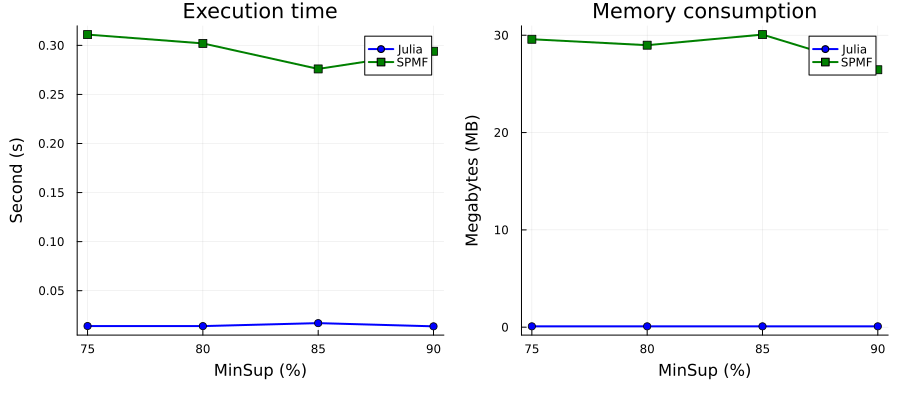

In [5]:
# ── Visualise Performance ─────────────────────────────────────────────────────
vis_performance(performance_result, logger)


### Evaluate Scalability

In [6]:
# ── Evaluation: Scalability (Time vs Data Size) ──────────────────────────────
scalability_result = eval_scalability(config, logger)


[process] Đang Warmup JIT Compiler...

__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Ngưỡng MinSup cố định=90.0%
[process] Data Ratio = 25.0% (25000 giao dịch) ...
   [metric] Julia Time: 0.004s | SPMF Time: 0.137s
[process] Data Ratio = 50.0% (50000 giao dịch) ...


Đang đo độ mở rộng...  50%|███████████████              |  ETA: 0:00:02

   [metric] Julia Time: 0.016s | SPMF Time: 0.189s
[process] Data Ratio = 75.0% (75000 giao dịch) ...


Đang đo độ mở rộng...  75%|██████████████████████       |  ETA: 0:00:01

   [metric] Julia Time: 0.014s | SPMF Time: 0.234s
[process] Data Ratio = 100.0% (100000 giao dịch) ...


Đang đo độ mở rộng... 100%|█████████████████████████████| Time: 0:00:03


   [metric] Julia Time: 0.015s | SPMF Time: 0.252s
[success] Saved at ../results/connect4_scalability.csv


Row,DataRatio,NumTransactions,JuliaTime,SPMFTime
,Float64,Int64,Float64,Float64
1,0.25,25000,0.0038732,0.137
2,0.5,50000,0.0159067,0.189
3,0.75,75000,0.0139156,0.234
4,1.0,100000,0.0150507,0.252



__________________________________________________
[phase]  visualize
__________________________________________________


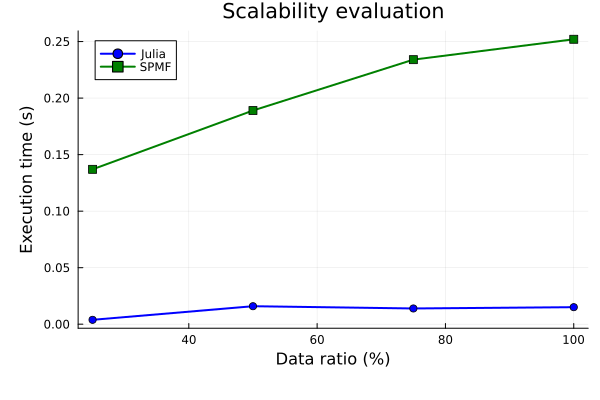

In [7]:
# ── Visualise Scalability ─────────────────────────────────────────────────────
vis_scalability(scalability_result, logger)


### Result

Bảng bên dưới hiển thị dữ liệu benchmark thô trực tiếp từ DataFrame.

In [ ]:
# ── Kết quả dạng bảng ───────────────────────────────────────────────────────
println("=== PERFORMANCE ===")
display(performance_result)
println()
println("=== SCALABILITY ===")
display(scalability_result)
